In [1]:
# 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')

# 필요한 7개 변수 리스트 (실제 파일의 컬럼명으로 수정 필요)
target_cols = [
    '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)',
    '최고기온(°C)', '최저기온(°C)',
    '최고기온 나타난날(yyyymmdd)', '최저기온 나타난날(yyyymmdd)'
]

# 변수별 결측치 확인
null_counts = df[target_cols].isnull().sum()
null_percent = (df[target_cols].isnull().sum() / len(df)) * 100

print(null_counts)
print(null_percent)

평균기온(°C)               0
평균최고기온(°C)             0
평균최저기온(°C)             0
최고기온(°C)               0
최저기온(°C)               0
최고기온 나타난날(yyyymmdd)    0
최저기온 나타난날(yyyymmdd)    0
dtype: int64
평균기온(°C)               0.0
평균최고기온(°C)             0.0
평균최저기온(°C)             0.0
최고기온(°C)               0.0
최저기온(°C)               0.0
최고기온 나타난날(yyyymmdd)    0.0
최저기온 나타난날(yyyymmdd)    0.0
dtype: float64


In [3]:
import pandas as pd

# 1. 데이터 불러오기 (기상청 데이터 특성상 cp949 인코딩 사용)
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

# 2. 분석에 필요한 7가지 핵심 변수 설정
target_cols = [
    '평균기온(°C)',
    '평균최고기온(°C)',
    '평균최저기온(°C)',
    '최고기온(°C)',
    '최저기온(°C)',
    '최고기온 나타난날(yyyymmdd)',
    '최저기온 나타난날(yyyymmdd)'
]

print("=== 4.1 결측치 확인 결과 ===")
# 변수별 결측치 개수
null_counts = df[target_cols].isnull().sum()
# 변수별 결측 비율 (%)
null_percent = (null_counts / len(df)) * 100

# 결과 출력
missing_info = pd.concat([null_counts, null_percent], axis=1)
missing_info.columns = ['결측치 개수', '결측 비율(%)']
print(missing_info)
print("\n")

print("=== 4.2 중복 데이터 확인 결과 ===")
# 전체 행이 완전히 일치하는 중복 데이터 확인
total_duplicates = df.duplicated().sum()

# 지점명과 일시(연도)가 모두 중복되는 데이터 확인 (데이터 ID 성격)
id_duplicates = df.duplicated(subset=['지점명', '일시']).sum()

print(f"전체 행 중복 개수: {total_duplicates}")
print(f"지점/일시(ID) 중복 개수: {id_duplicates}")

# 3. [선택 사항] 결측치 제거 후 데이터 저장
# 분석의 정확도를 위해 결측치가 있는 행을 제거한 데이터프레임을 생성합니다.
df_clean = df.dropna(subset=target_cols)

print("\n=== 데이터 정제 결과 ===")
print(f"원래 데이터 행 수: {len(df)}")
print(f"정제 후 데이터 행 수: {len(df_clean)}")
print(f"제거된 행 수: {len(df) - len(df_clean)}")

# 정제된 데이터를 새로운 파일로 저장하고 싶을 때 사용하세요
df_clean.to_csv('기상_데이터_정제본.csv', index=False, encoding='cp949')

=== 4.1 결측치 확인 결과 ===
                     결측치 개수  결측 비율(%)
평균기온(°C)                  6  2.325581
평균최고기온(°C)                4  1.550388
평균최저기온(°C)                4  1.550388
최고기온(°C)                  0  0.000000
최저기온(°C)                  0  0.000000
최고기온 나타난날(yyyymmdd)       0  0.000000
최저기온 나타난날(yyyymmdd)       0  0.000000


=== 4.2 중복 데이터 확인 결과 ===
전체 행 중복 개수: 0
지점/일시(ID) 중복 개수: 0

=== 데이터 정제 결과 ===
원래 데이터 행 수: 258
정제 후 데이터 행 수: 252
제거된 행 수: 6


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

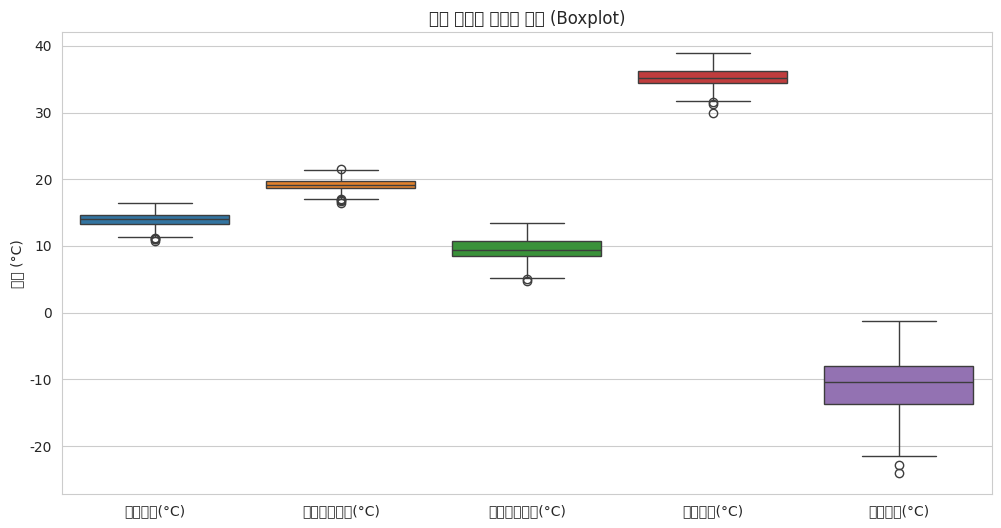

=== 4.3 이상치 분석 결과 ===
[평균기온(°C)] 기준: 11.20 ~ 16.80 / 이상치 개수: 4
[평균최고기온(°C)] 기준: 17.05 ~ 21.45 / 이상치 개수: 5
[평균최저기온(°C)] 기준: 5.14 ~ 14.04 / 이상치 개수: 2
[최고기온(°C)] 기준: 31.70 ~ 38.90 / 이상치 개수: 3
[최저기온(°C)] 기준: -22.31 ~ 0.59 / 이상치 개수: 2


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 정제 (결측치 제거)
df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
target_cols = ['평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)']
df_clean = df.dropna(subset=target_cols)

# 2. 이상치 확인을 위한 통계량 계산 함수
def get_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return lower_bound, upper_bound, len(outliers)

# 3. 시각화 및 결과 출력
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[target_cols])
plt.title('기온 변수별 이상치 확인 (Boxplot)')
plt.ylabel('기온 (°C)')
plt.show()

print("=== 4.3 이상치 분석 결과 ===")
for col in target_cols:
    low, high, count = get_outliers(df_clean, col)
    print(f"[{col}] 기준: {low:.2f} ~ {high:.2f} / 이상치 개수: {count}")

In [7]:
import pandas as pd

# 1. 파일 불러오기
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')

# 2. 분석할 5개 핵심 기온 변수 설정
target_cols = ['평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)']

# 3. 결측치를 제거한 새로운 데이터프레임 생성 (df_clean)
# 이 데이터로 분석해야 수치가 정확하게 나옵니다.
df_clean = df.dropna(subset=target_cols)

# 4. 기술 통계량 산출 (평균, 표준편차, 최솟값, 25%, 50%(중앙값), 75%, 최댓값)
stats_summary = df_clean[target_cols].describe()

# 5. 중앙값(Median)과 왜도(Skewness) 추가 계산
stats_summary.loc['median'] = df_clean[target_cols].median()
stats_summary.loc['skewness'] = df_clean[target_cols].skew()

# 결과 출력 (소수점 둘째자리까지)
print("=== 5.1 수치형 변수 기술 통계 요약 ===")
print(stats_summary.round(2))

print("\n--- [보고서 작성 팁] ---")
print(f"최종 분석에 사용된 데이터 수: {len(df_clean)}개")

=== 5.1 수치형 변수 기술 통계 요약 ===
          평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)
count       252.00      252.00      252.00    252.00    252.00
mean         13.95       19.21        9.43     35.23    -10.94
std           1.05        0.89        1.65      1.38      4.04
min          10.80       16.50        4.80     29.90    -24.10
25%          13.30       18.70        8.48     34.40    -13.72
50%          14.00       19.20        9.40     35.20    -10.45
75%          14.70       19.80       10.70     36.20     -8.00
max          16.50       21.50       13.40     38.90     -1.20
median       14.00       19.20        9.40     35.20    -10.45
skewness     -0.36       -0.23       -0.11     -0.28     -0.39

--- [보고서 작성 팁] ---
최종 분석에 사용된 데이터 수: 252개


In [8]:
# '지점명'으로 그룹을 묶어서 각 지역별 표준편차(std)만 계산
region_std = df_clean.groupby('지점명')[target_cols].std()

print("=== 지역별 기온 표준편차(std) 확인 ===")
print(region_std.round(2))

# 가장 변동이 심한 지역과 안정적인 지역 확인용
print("\n--- 분석 결과 ---")
print(f"최저기온 변동이 가장 큰 지역: {region_std['최저기온(°C)'].idxmax()}")
print(f"최저기온이 가장 안정적인 지역: {region_std['최저기온(°C)'].idxmin()}")

=== 지역별 기온 표준편차(std) 확인 ===
         평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)
지점명                                                          
강진군          0.58        0.64        0.58      1.22      3.42
고창           0.38        0.34        0.50      1.03      2.80
고창군          0.63        0.55        0.72      1.13      3.09
고흥           0.66        0.75        0.74      1.27      2.36
광양시          0.38        0.46        0.42      1.17      2.30
군산           0.49        0.44        0.56      0.80      2.95
남원           0.60        0.48        0.75      1.07      3.12
목포           0.50        0.51        0.52      1.06      2.99
보성군          0.48        0.48        0.63      0.74      2.08
부안           0.58        0.50        0.67      0.88      3.38
순창군          0.67        0.57        0.81      1.00      3.48
순천           0.40        0.34        0.58      1.20      2.51
여수           0.41        0.41        0.42      1.00      2.07
영광군          0.61        0.49        0.74 

/tmp/ipykernel_14571/3702512114.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='지점명', order=category_counts.index, palette='pastel')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4

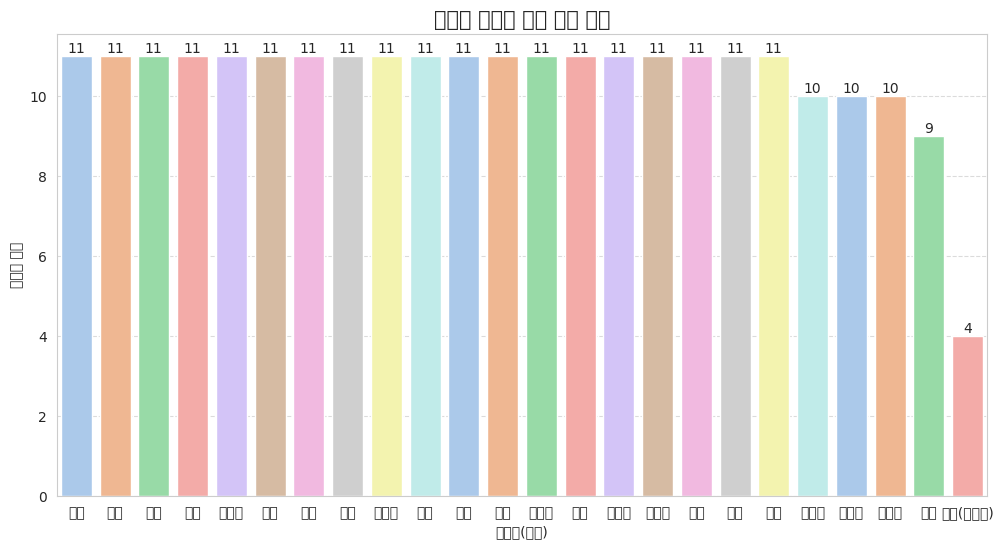


       [ 5.2 범주형 변수(지점명) 분석 상세 결과 ]
         빈도(개수)  비율(%)
지점명                   
군산           11   4.37
전주           11   4.37
목포           11   4.37
여수           11   4.37
흑산도          11   4.37
완도           11   4.37
순천           11   4.37
부안           11   4.37
광양시          11   4.37
임실           11   4.37
정읍           11   4.37
남원           11   4.37
고창군          11   4.37
장수           11   4.37
보성군          11   4.37
순창군          11   4.37
장흥           11   4.37
고흥           11   4.37
해남           11   4.37
강진군          10   3.97
진도군          10   3.97
영광군          10   3.97
고창            9   3.57
진도(첨찰산)       4   1.59
--------------------------------------------------
총 데이터 개수: 252개
고유 지역 수: 24개


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 불러오기 및 데이터 정제
df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
target_cols = ['평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)']
df_clean = df.dropna(subset=target_cols)

# 2. 범주형 변수(지점명) 빈도 및 비율 계산
category_counts = df_clean['지점명'].value_counts()
category_percent = df_clean['지점명'].value_counts(normalize=True) * 100

# 표 형태로 출력하기 위해 데이터프레임 생성
category_analysis = pd.concat([category_counts, category_percent], axis=1)
category_analysis.columns = ['빈도(개수)', '비율(%)']

# 3. 시각화 (막대그래프)
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_clean, x='지점명', order=category_counts.index, palette='pastel')

# 막대 위에 숫자 표시 (추가된 부분)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('지역별 데이터 수집 빈도 확인', fontsize=15)
plt.xlabel('지점명(지역)')
plt.ylabel('데이터 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. 아래에 텍스트 결과 출력 (요청하신 부분)
print("\n" + "="*50)
print("       [ 5.2 범주형 변수(지점명) 분석 상세 결과 ]")
print("="*50)
print(category_analysis.round(2))
print("-" * 50)
print(f"총 데이터 개수: {len(df_clean)}개")
print(f"고유 지역 수: {len(category_counts)}개")
print("="*50)

In [13]:
import pandas as pd

# 1. 파일 불러오기
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')

print("=== 4.4 데이터 일관성 점검 결과 ===\n")

# [체크 1] 지점명 불일치 및 오탈자 확인 (비슷한 이름이 있는지 확인)
print("1. 지점명 일관성:")
unique_locations = sorted(df['지점명'].unique())
print(f"고유 지점 수: {len(unique_locations)}개")
print(f"지점 리스트: {unique_locations[:5]} ... 등")

# [체크 2] 날짜 형식 오류 점검 (날짜로 변환되지 않는 값이 있는지)
print("\n2. 날짜 형식 일관성:")
invalid_dates = pd.to_datetime(df['일시'], errors='coerce').isna().sum()
if invalid_dates == 0:
    print("결과: 모든 날짜 데이터가 올바른 형식입니다.")
else:
    print(f"경고: {invalid_dates}개의 날짜 데이터에 오류가 있습니다.")

# [체크 3] 온도 단위 및 논리적 오류 점검 (최고기온이 최저기온보다 낮은 경우 등)
print("\n3. 온도 데이터 논리성 검사:")
logic_error = df[df['최고기온(°C)'] < df['최저기온(°C)']]
if len(logic_error) == 0:
    print("결과: 최고기온이 최저기온보다 낮은 논리적 오류가 없습니다.")
else:
    print(f"경고: {len(logic_error)}건의 논리적 오류 데이터 발견!")

# [체크 4] 범주형 변수 공백 확인
space_check = df['지점명'].str.contains(' ').sum()
print(f"\n4. 텍스트 공백 검사: 지점명 내 불필요한 공백 {space_check}건 발견")

=== 4.4 데이터 일관성 점검 결과 ===

1. 지점명 일관성:
고유 지점 수: 24개
지점 리스트: ['강진군', '고창', '고창군', '고흥', '광양시'] ... 등

2. 날짜 형식 일관성:
결과: 모든 날짜 데이터가 올바른 형식입니다.

3. 온도 데이터 논리성 검사:
결과: 최고기온이 최저기온보다 낮은 논리적 오류가 없습니다.

4. 텍스트 공백 검사: 지점명 내 불필요한 공백 0건 발견


/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14571/613001568.py:25: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight

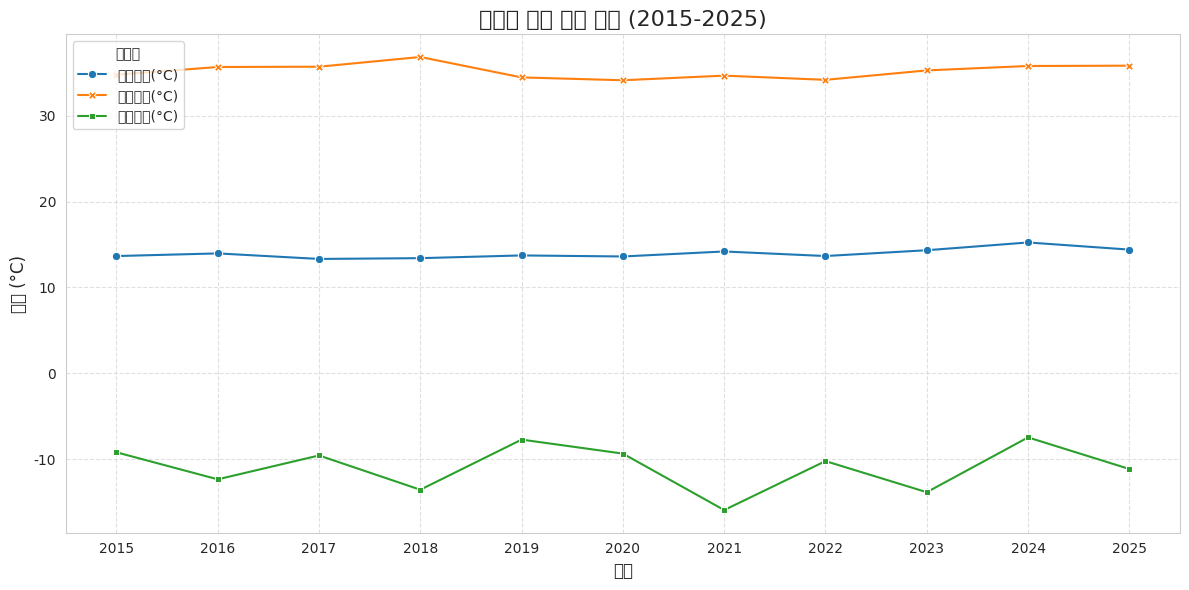

=== 연도별 평균 데이터 ===
      평균기온(°C)  최고기온(°C)  최저기온(°C)
연도                                
2015     13.66     34.80     -9.20
2016     13.97     35.69    -12.35
2017     13.33     35.73     -9.57
2018     13.42     36.86    -13.57
2019     13.73     34.48     -7.73
2020     13.61     34.15     -9.36
2021     14.20     34.69    -15.94
2022     13.67     34.20    -10.23
2023     14.34     35.30    -13.85
2024     15.25     35.81     -7.47
2025     14.41     35.85    -11.15


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 불러오기 및 데이터 정제
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')
df['연도'] = df['일시'].astype(str).str[:4].astype(int) # '일시'에서 연도 추출

# 2. 연도별 평균치 계산
yearly_avg = df.groupby('연도')[['평균기온(°C)', '최고기온(°C)', '최저기온(°C)']].mean()

# 3. 시각화 (선그래프)
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, markers=True, dashes=False)

plt.title('연도별 기온 변화 추세 (2015-2025)', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('온도 (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='변수명', loc='upper left')

# X축 연도를 정수로 표시
plt.xticks(yearly_avg.index)

plt.tight_layout()
plt.show()

# 4. 분석 수치 출력
print("=== 연도별 평균 데이터 ===")
print(yearly_avg.round(2))

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

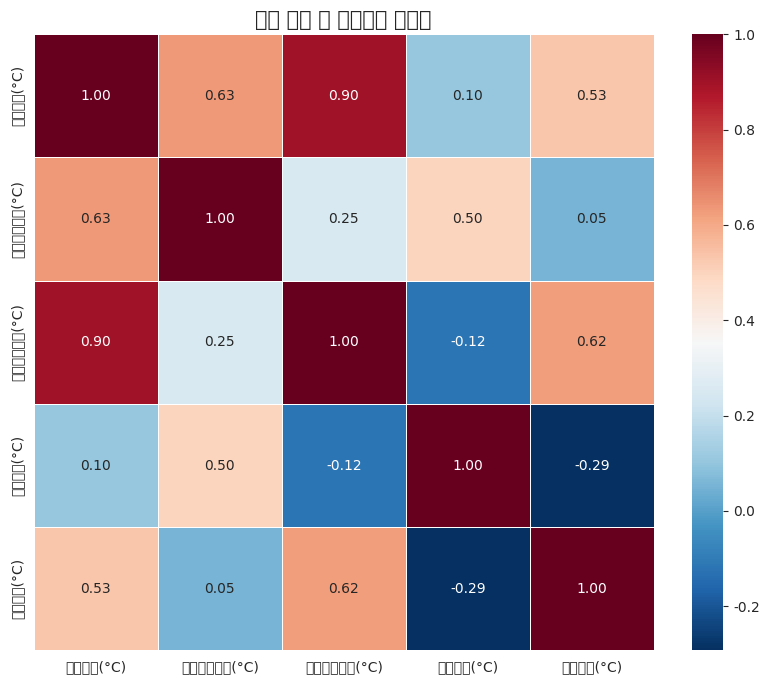

=== 상관계수 결과 테이블 ===
            평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)
평균기온(°C)        1.00        0.63        0.90      0.10      0.53
평균최고기온(°C)      0.63        1.00        0.25      0.50      0.05
평균최저기온(°C)      0.90        0.25        1.00     -0.12      0.62
최고기온(°C)        0.10        0.50       -0.12      1.00     -0.29
최저기온(°C)        0.53        0.05        0.62     -0.29      1.00


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기 및 정제
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')
target_cols = ['평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)']
df_clean = df.dropna(subset=target_cols)

# 2. 상관계수 계산
corr_matrix = df_clean[target_cols].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)
plt.title('기온 변수 간 상관관계 히트맵', fontsize=15)
plt.show()

# 4. 수치 결과 출력
print("=== 상관계수 결과 테이블 ===")
print(corr_matrix.round(2))